# FourPair

Edit `bandage`, `preference`, `diagram_mode`, `face_colors`, and the `graph_*` options before running the cells using the **v2/.venv** kernel, with GAP on `PATH`.


In [1]:
import bce_v2 as c
from bce_v2.notebook import refresh_renderers
from IPython.display import Markdown, display

refresh_renderers()

bandage = [
    0, 0, 0,
    0, 0, 0,
    0, 0, 0,

    1, 0, 2,
    0, 0, 0,
    3, 0, 4,

    1, 0, 2,
    0, 0, 0,
    3, 0, 4,
]

preference = "memory"
diagram_mode = c.DiagramMode.OPPOSITE_CORNERS
face_colors = {
    'U': 'white', 'R': 'red', 'F': 'green',
    'D': 'yellow', 'L': 'orange', 'B': 'blue',
}

analysis = c.analyze_isotropy(bandage)
display(Markdown(
    "| Shapes | Isotropy group size | Total scrambles |\n"
    "| ---: | ---: | ---: |\n"
    f"| {analysis.loops.shape_count:,} | {analysis.group_order:,} | {analysis.colored_state_count:,} |"
))

| Shapes | Isotropy group size | Total scrambles |
| ---: | ---: | ---: |
| 4,062 | 40,131,624,960 | 163,014,660,587,520 |

Compile the staged guide. Graph rendering is a separate optional cell below.
Progress is printed while compiling. The 120-second optimization budget starts after a certified baseline is available.


# Solution from solved shape

This computational method covers all **40,131,624,960 reachable colored states** whose bandage shape is already the declared reference shape.

In each stage's diagrams: face centers are colored to inform you how to orient the cube before algorithm application. Blocks already solved are dark grey. The block this stage requires you to identify is colored. Striped white color indicates a white sticker, plain white indicates unsolved sticker of any color.

## Algorithms

Singmaster notation uses U/R/F/D/L/B, an apostrophe for an inverse turn, 2 for a half turn, x/y/z represent whole cube rotations 90° in the direction of an R/U/F move respectively. Structured recipes use `[A, B] = A B A⁻¹ B⁻¹`, `S^A = A⁻¹ S A`, and signed powers; a negative power executes the inverse algorithm.

| Turn sequence | Block action | Structure |
| --- | --- | --- |
| `M2: B2 L2 B2` | `(UBR UFL)(UL DL)([BR-DBR] [FL-DFL])` | `L2^B2` |
| `M3: B2 R2 B2` | `(UBL UFR)(UR DR)([BL-DBL] [FR-DFR])` | `R2^B2` |
| `M4: B2 F2 L2 R2` | `(UBL UFR)(UB DB)(UBR UFL)(UL DL)(UR DR)(UF DF)([BL-DBL] [FR-DFR])([BR-DBR] [FL-DFL])` | `B2 F2 L2 R2` |
| `M5: B F D2 F' B'` | `(UBL UFR)([BL-DBL] [FR-DFR])(DL DR)` | `D2^(F' B')` |
| `M6: B F U2 F' B'` | `(UBR UFL)(UL UR)([BR-DBR] [FL-DFL])` | `U2^(F' B')` |
| `M7: B F' L F B'` | `(UBL UBR UFR UFL)(UB+ UL+ UF+ DL+)` | `L^(F B')` |
| `M8: B' F R F' B` | `(UBL UBR UFR UFL)(UB+ DR+ UF+ UR+)` | `R^(F' B)` |
| `M9: B' F' D2 F B` | `(UBR UFL)([BR-DBR] [FL-DFL])(DL DR)` | `D2^(F B)` |
| `M11: U B2 L2 B2 U'` | `(UBL UFR)(UF DL)([BR-DBR] [FL-DFL])` | `L2^(B2 U')` |
| `M12: U B2 R2 B2 U'` | `(UB DR)(UBR UFL)([BL-DBL] [FR-DFR])` | `R2^(B2 U')` |
| `M13: U' B2 L2 B2 U` | `(UBL UFR)(UB DL)([BR-DBR] [FL-DFL])` | `L2^(B2 U)` |
| `M14: U' B2 R2 B2 U` | `(UBR UFL)(UF DR)([BL-DBL] [FR-DFR])` | `R2^(B2 U)` |
| `M15: U2 B2 R2 B2 U2` | `(UBL UFR)(UL DR)([BL-DBL] [FR-DFR])` | `R2^(B2 U2)` |
| `M22: B L U L' U' B'` | `(UBL UBR+)(UB+ UL UF+)(UFL UFR-)` | `[L, U]^B'` |
| `M23: B U' L2 B2 U' L` | `(UBL- UFR-)(UB+ DL UF)(UBR- UFL)(UL UR DB+)([BL-DBL] [FL-DFL] [BR-DBR])` | `B U' L2 B2 U' L` |
| `M24: B' F D U' R' L` | `(UBL UFL UFR UBR)(UB+ UR)(UL UF+ DR DB+)([BL-DBL] [FL-DFL] [FR-DFR] [BR-DBR])(DL DF+)` | `B' F D U' R' L` |
| `M28: B U B' U' L' B' L` | `(UBL+ UBR)(UB+)(UL DB+)(UFL-)` | `[B, U] B'^L` |
| `M29: B' R B U R U' R F2 R' U R' U' B' R' B R2 F2 R2` | `(UBR UFL+ UFR-)` | `F2^(R' R'^U' R'^B) F2^R2` |
| `M30: B L U L' U' B' L2 F2 L2 B U L U' L' B' U' L2 F2 L2 U` | `(UBR+)(UFL-)` | `F2^(L2 [U, L]^B') F2^(L2 U)` |
| `M31: B' F R' F' B L2 B2 L2 B' F R F' B U2 L' U B2 L2 U B R2 B' U' L2 B2 U' L U2` | `([BR-DBR] [FR-DFR] [FL-DFL])(DB+)(DR+)` | `B2^(L2 R^(F' B)) R2^(B' U' L2 B2 U' L U2)` |

### Shared piece recipes

| Piece | Turn sequence |
| --- | --- |
| `C1` | `L U L' U'` |
| `C2` | `U' L2 B2 U' L` |
| `C3` | `B' R B U R U' R` |
| `C4` | `L2 F2 L2` |

| Algorithm | Recipe |
| --- | --- |
| `M2` | `(B2) (L2) (B2)^-1` |
| `M3` | `(B2) (R2) (B2)^-1` |
| `M4` | `B2 F2 L2 R2` |
| `M5` | `(B F) (D2) (B F)^-1` |
| `M6` | `(B F) (U2) (B F)^-1` |
| `M7` | `(B F') (L) (B F')^-1` |
| `M8` | `(B' F) (R) (B' F)^-1` |
| `M9` | `(B' F') (D2) (B' F')^-1` |
| `M11` | `(U B2) (L2) (U B2)^-1` |
| `M12` | `(U B2) (R2) (U B2)^-1` |
| `M13` | `(U' B2) (L2) (U' B2)^-1` |
| `M14` | `(U' B2) (R2) (U' B2)^-1` |
| `M15` | `(U2 B2) (R2) (U2 B2)^-1` |
| `M22` | `(B) (C1) (B)^-1` |
| `M23` | `B C2` |
| `M24` | `B' F D U' R' L` |
| `M28` | `y' (C1) y L' B' L` |
| `M29` | `C3 F2 C3^-1 z2 (C4) z2` |
| `M30` | `B C1 B' C4 B C1^-1 B' U' C4 U` |
| `M31` | `B' F R' F' B x2 (C4) x2 B' F R F' B U2 C2^-1 B R2 B' C2 U2` |

## Stage 1: Solve Edge UB

This stage has 16 exact cases and 13 instruction families. It reduces the remaining possibilities from 40,131,624,960 to 2,508,226,560.

### Case 1

Skip — already correct

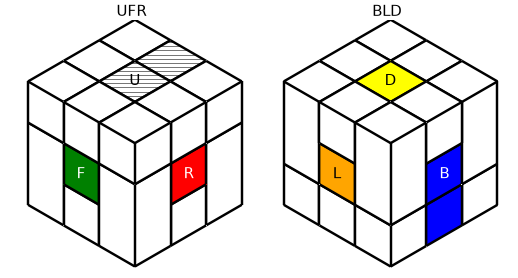

### Case 2

Execute `(U' (y' (M7) y)^-1)^-1: R L' B L R' U`.

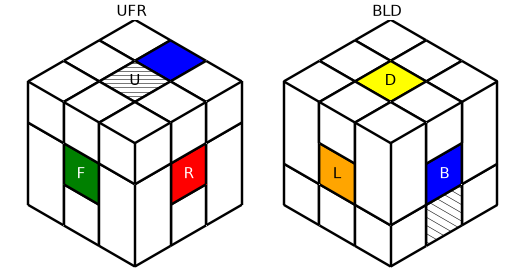

### Case 3

Execute `U: U`.

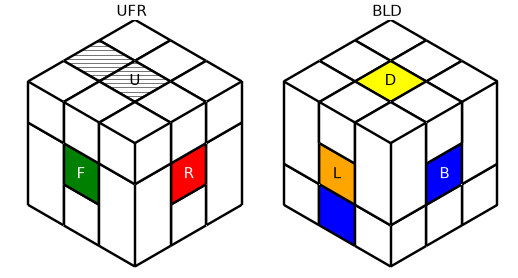

### Case 4

Execute `M7^-1: B F' L' F B'`.

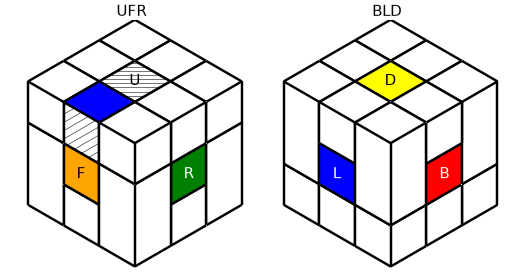

### Case 5

Execute `U': U'`.

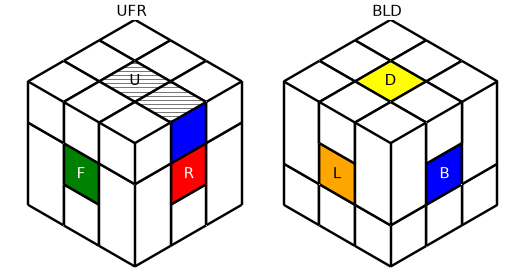

### Case 6

Execute `M7: B F' L F B'`.

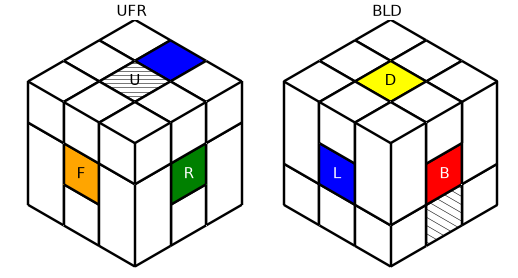

### Case 7

Execute `U2: U2`.

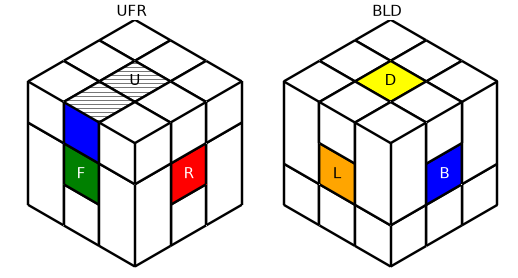

### Case 8

Execute `M22^-1: B U L U' L' B'`.

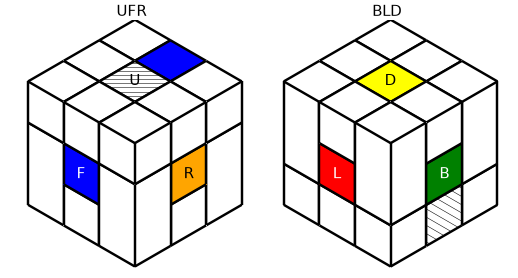

### Case 9

Execute `M3: B2 R2 B2`.

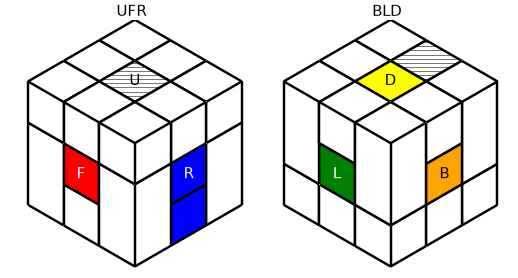

### Case 10

Execute `(U' y' (M7) y)^-1: R L' B' L R' U`.

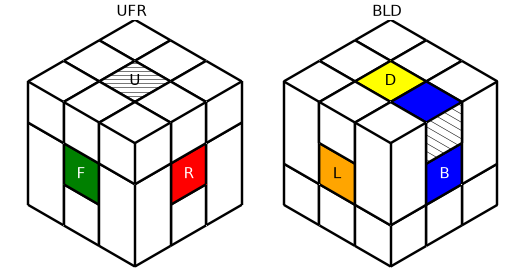

### Case 11

Execute `(U' y2 (M3) y2)^-1: F2 L2 F2 U`.

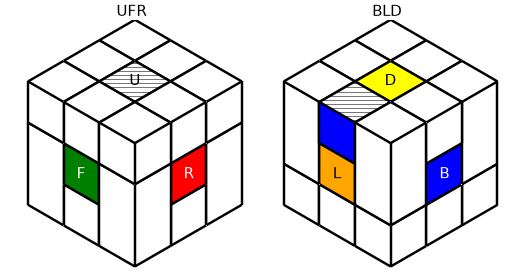

### Case 12

Execute `M8: B' F R F' B`.

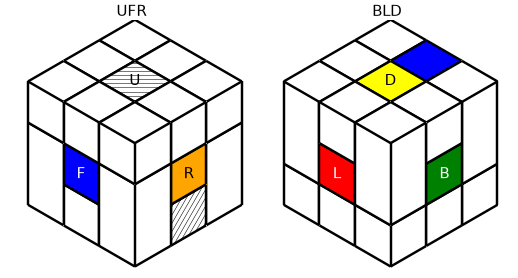

### Case 13

Execute `(U y2 (M2) y2)^-1: F2 R2 F2 U'`.

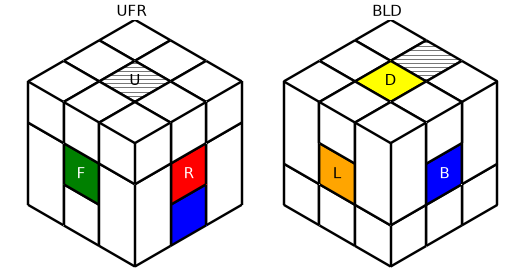

### Case 14

Execute `M7^-1: B F' L' F B'`.

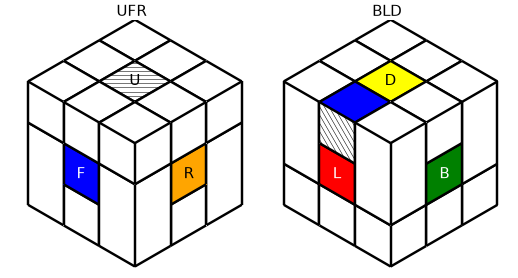

### Case 15

Execute `(U2 y (M2) y')^-1: L2 F2 L2 U2`.

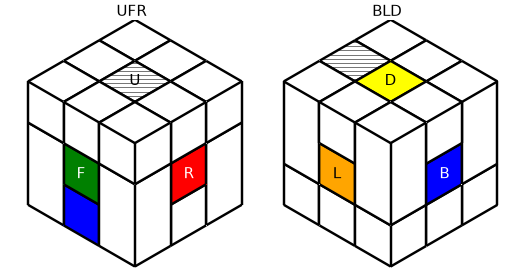

### Case 16

Execute `(U' (y' (M8) y)^-1)^-1: R' L F L' R U`.

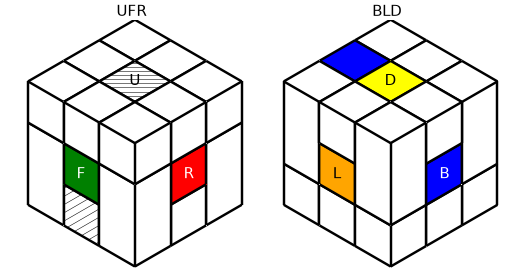

Also correct automatically after this stage: place Edge UB.

## Stage 2: Solve Edge UR

This stage has 14 exact cases and 12 instruction families. It reduces the remaining possibilities from 2,508,226,560 to 179,159,040.

### Case 1

Execute `M8^-2: B' F R2 F' B`.

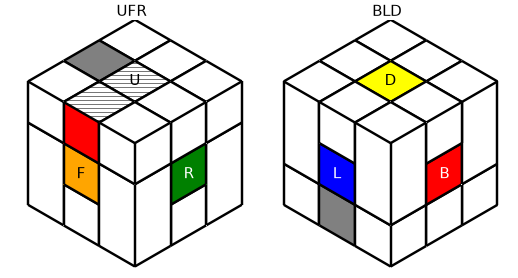

### Case 2

Execute `M22^-1: B U L U' L' B'`.

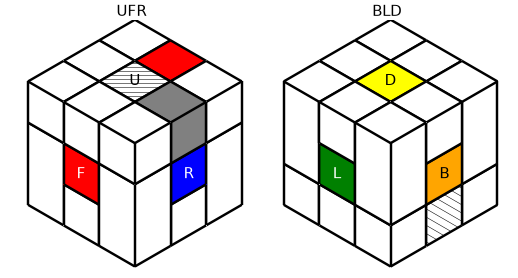

### Case 3

Skip — already correct

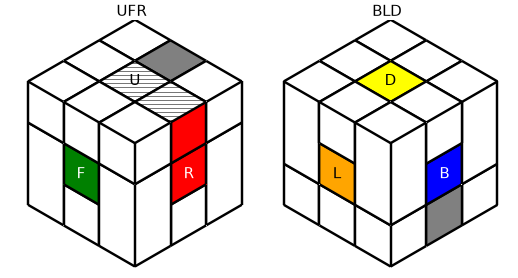

### Case 4

Execute `(U' (y' (M22) y)^-1)^-1: R B U B' U' R' U`.

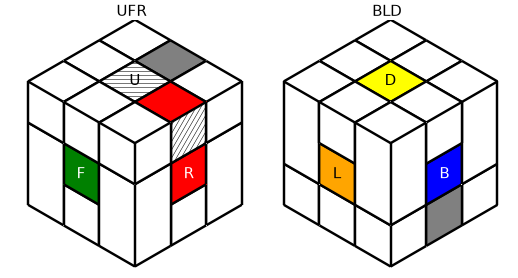

### Case 5

Execute `M22: B L U L' U' B'`.

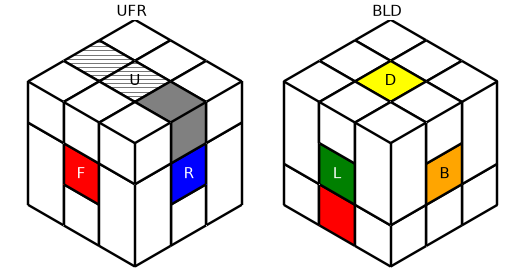

### Case 6

Execute `M8: B' F R F' B`.

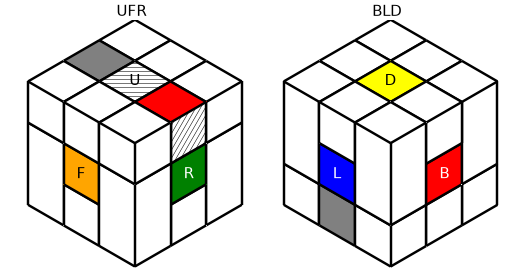

### Case 7

Execute `M14: U' B2 R2 B2 U`.

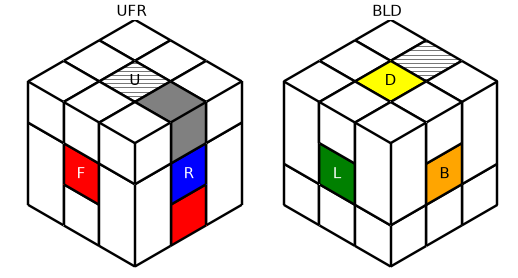

### Case 8

Execute `(U2 y' (M7) y U2)^-1: U2 R L' B' L R' U2`.

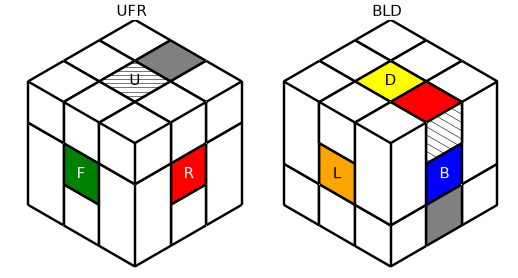

### Case 9

Execute `M15: U2 B2 R2 B2 U2`.

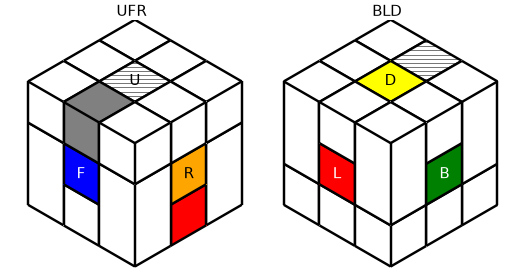

### Case 10

Execute `((y2 (M8) y2)^(U'))^-1: U F' B L' B' F U'`.

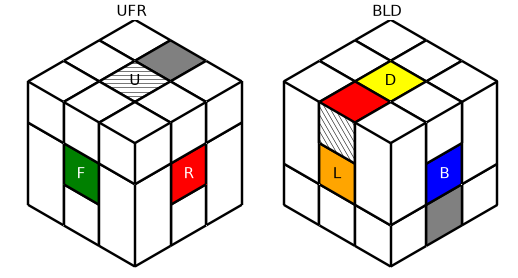

### Case 11

Execute `M2: B2 L2 B2`.

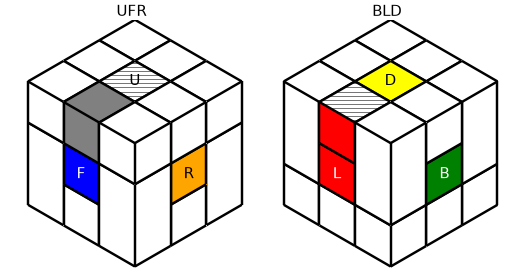

### Case 12

Execute `((y2 (M7) y2)^U)^-1: U' F B' R' B F' U`.

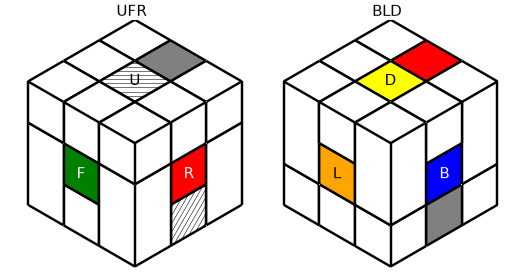

### Case 13

Execute `M11: U B2 L2 B2 U'`.

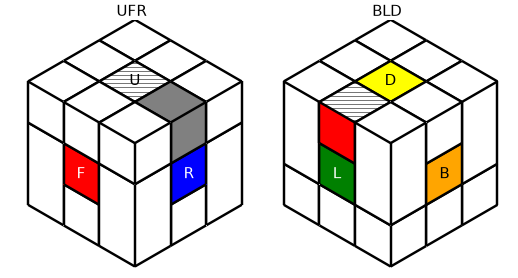

### Case 14

Execute `M8^-1: B' F R' F' B`.

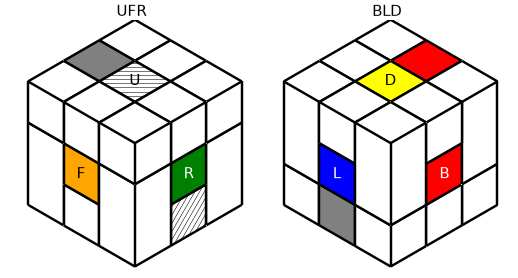

Also correct automatically after this stage: place Edge UR.

## Stage 3: Solve Edge UL

This stage has 12 exact cases and 11 instruction families. It reduces the remaining possibilities from 179,159,040 to 14,929,920.

### Case 1

Skip — already correct

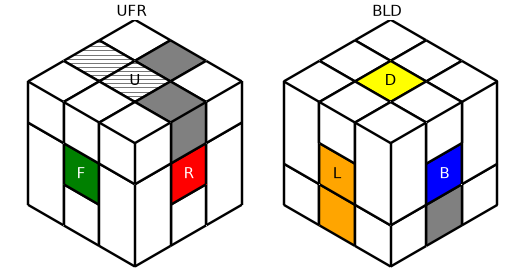

### Case 2

Execute `((y2 (M28) y2)^-1)^U: U' R' F R U F U' F' U`.

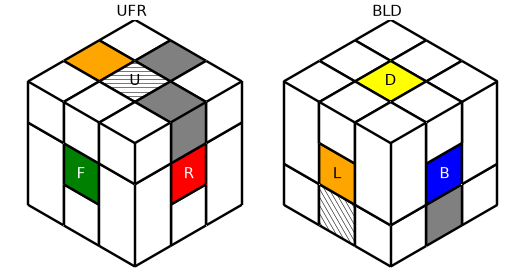

### Case 3

Execute `([U', y (M2) y'])^-1: L2 F2 L2 U' L2 F2 L2 U`.

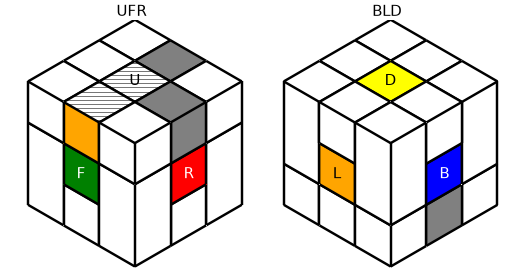

### Case 4

Execute `(M6^M7)^-1: B F' L' F2 U2 F2 L F B'`.

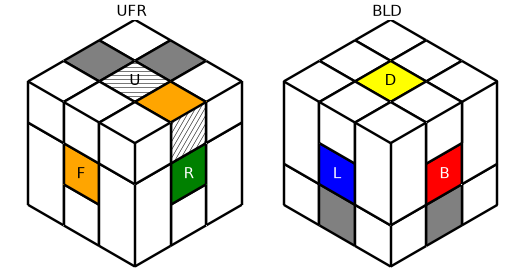

### Case 5

Execute `M12: U B2 R2 B2 U'`.

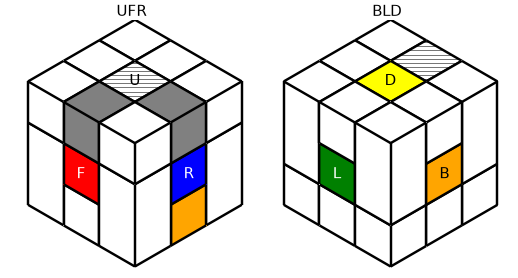

### Case 6

Execute `(M9^M8)^-1: B' F R' F2 D2 F2 R F' B`.

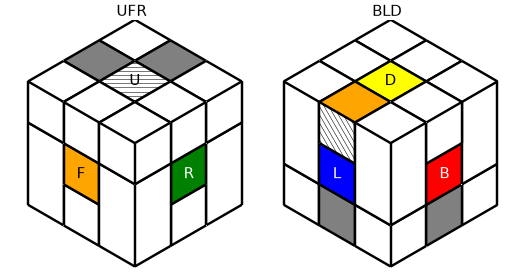

### Case 7

Execute `M3: B2 R2 B2`.

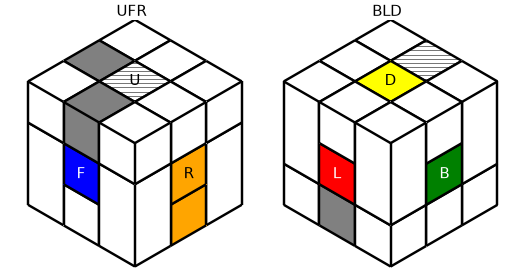

### Case 8

Execute `((((y2 (M28) y2)^-1)^U)^-1 y2 (M3) y2)^-1: F2 L2 F2 U' R' F R U F U' F' U`.

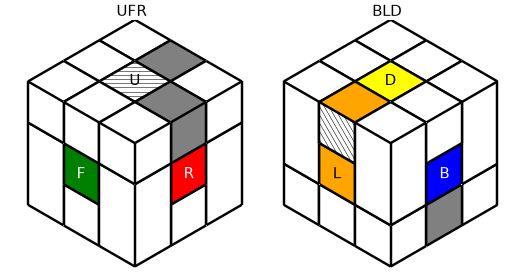

### Case 9

Execute `((y2 (M2) y2)^((U2 y2 (M2) y2)^-1))^-1: U2 F2 R2 F2 U2`.

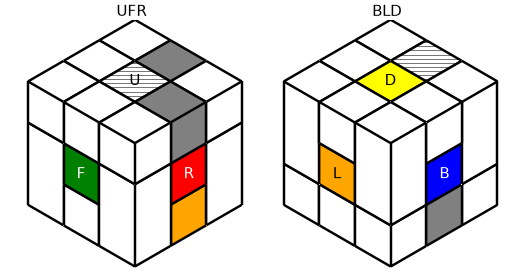

### Case 10

Execute `(y (M22) y')^((y2 (M2) y2)^-1): F2 R2 F2 L F U F' U' L' F2 R2 F2`.

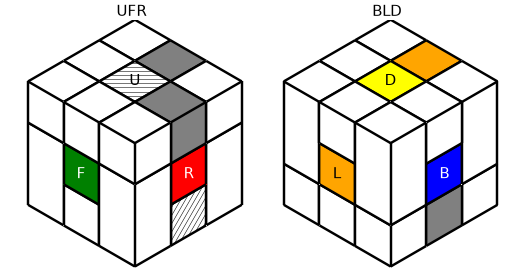

### Case 11

Execute `M13: U' B2 L2 B2 U`.

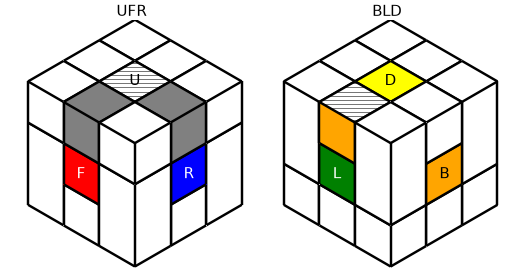

### Case 12

Execute `(U2 (y2 (M23) y2)^-1)^-1: F U' R2 F2 U' R U2`.

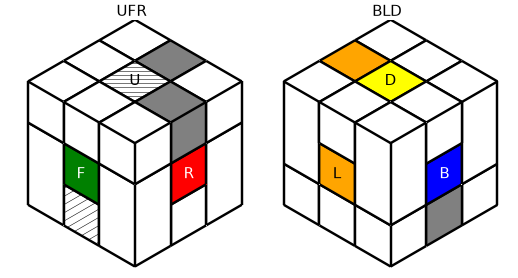

Also correct automatically after this stage: place Edge UL.

## Stage 4: Solve Edge UF

This stage has 10 exact cases and 9 instruction families. It reduces the remaining possibilities from 14,929,920 to 1,492,992.

### Case 1

Skip — already correct

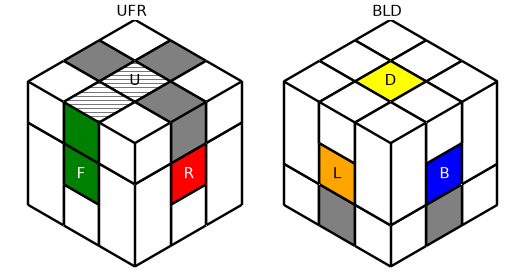

### Case 2

Execute `(y2 (M28) y2 y (M11) y')^-1: U L2 F2 L2 U' R' F R U F U' F'`.

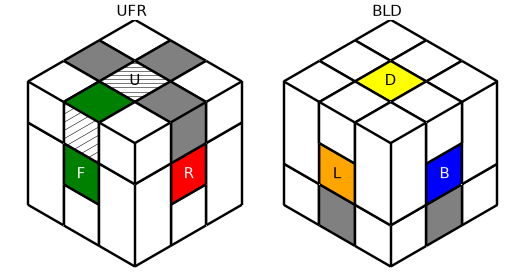

### Case 3

Execute `M15: U2 B2 R2 B2 U2`.

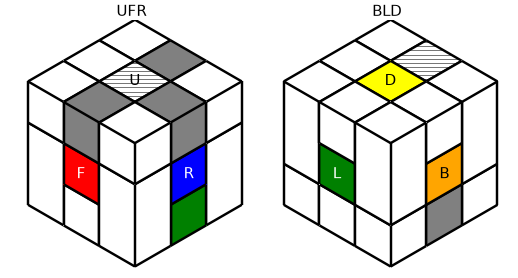

### Case 4

Execute `((y2 (M8) y2)^(U') U y2 (M24) y2 (y' (M8) y)^-1 y' (M9) y)^-1: R' L' D2 L2 F U D' L' B' F U'`.

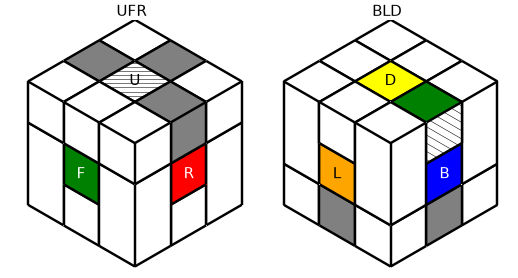

### Case 5

Execute `M11: U B2 L2 B2 U'`.

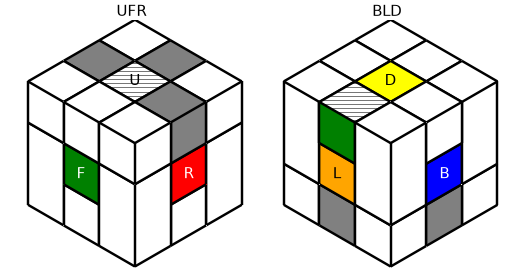

### Case 6

Execute `(M8^M4)^-1: R2 L2 F2 B F R' F' B' F2 L2 R2`.

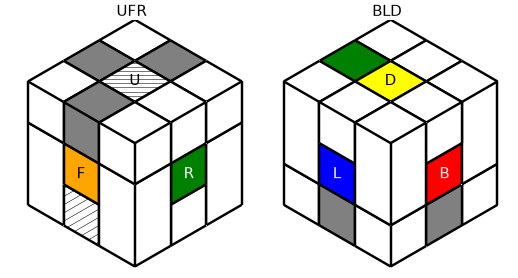

### Case 7

Execute `M14: U' B2 R2 B2 U`.

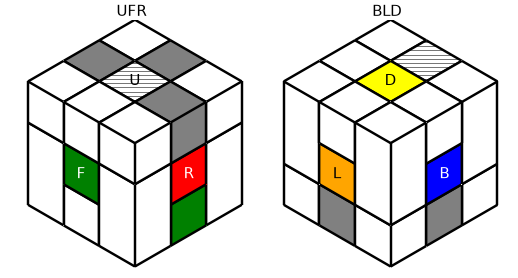

### Case 8

Execute `(y2 (M23) y2 U2 y (M13) y')^-1: U' L2 F2 L2 U' R' U F2 R2 U F'`.

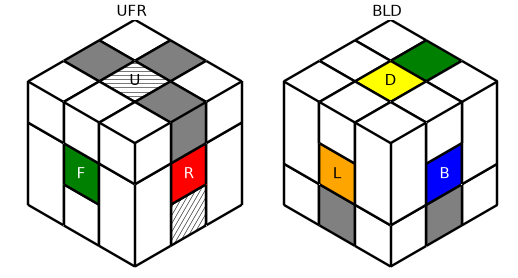

### Case 9

Execute `M2: B2 L2 B2`.

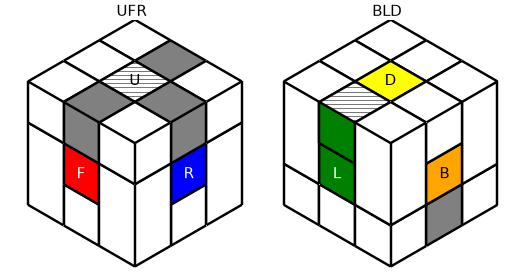

### Case 10

Execute `((y2 (M8) y2)^(U') U y2 (M24) y2 (y' (M8) y)^-1)^-1: R' L F U D' L' B' F U'`.

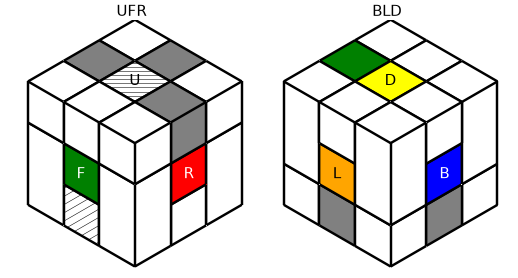

Also correct automatically after this stage: place Edge UF.

## Stage 5: Solve Corner UFL

This stage has 12 exact cases and 11 instruction families. It reduces the remaining possibilities from 1,492,992 to 124,416.

### Case 1

Execute `(U^(y' (M4) y))^-1: F2 B2 L2 R2 U' R2 L2 B2 F2`.

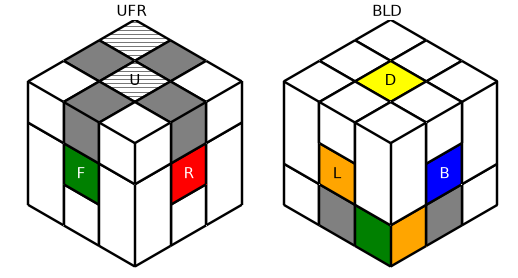

### Case 2

Execute `M22^-3: B U L U' L' U L U' L' U L U' L' B'`.

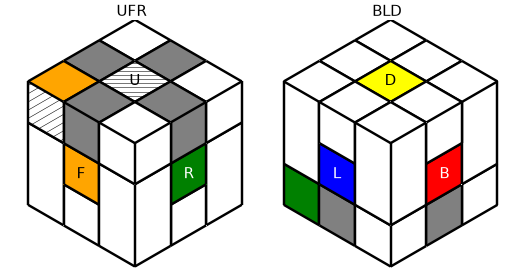

### Case 3

Execute `M29: B' R B U R U' R F2 R' U R' U' B' R' B R2 F2 R2`.

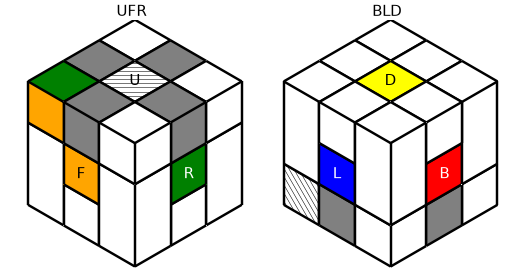

### Case 4

Execute `M5: B F D2 F' B'`.

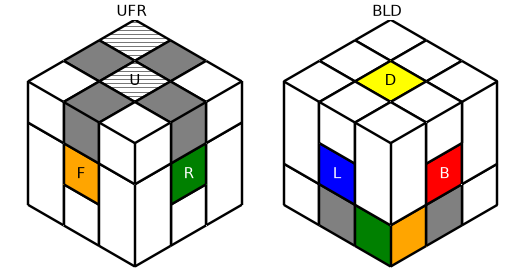

### Case 5

Execute `([M3, M22])^-1: B L U L' U' B R2 B' U L U' L' B R2 B2`.

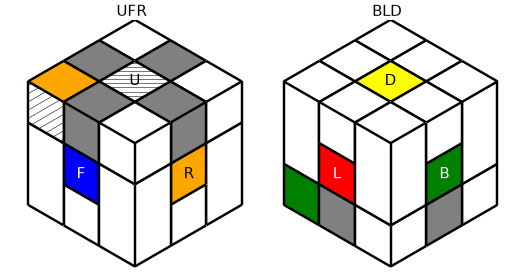

### Case 6

Execute `([M3, M22^-1])^-1: B U L U' L' B R2 B' L U L' U' B R2 B2`.

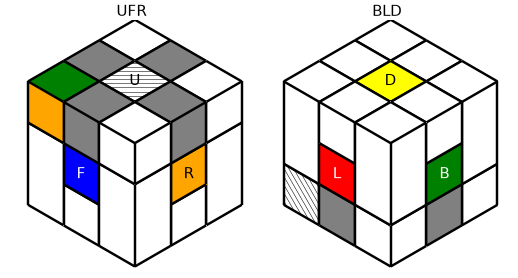

### Case 7

Skip — already correct

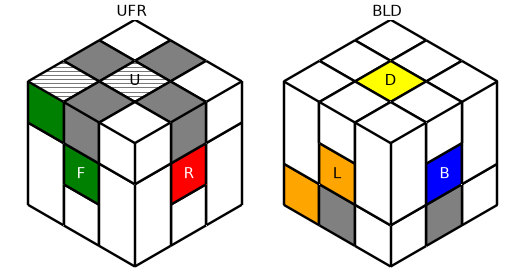

### Case 8

Execute `(((M28^-1)^-2)^(M2^-1))^-1: B2 L2 B2 L' B L U B U' B' L' B L U B U' B L2 B2`.

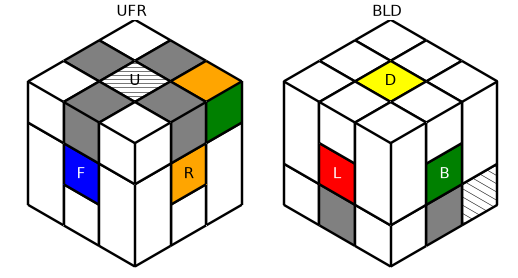

### Case 9

Execute `(((M28^-1)^2)^(M2^-1))^-1: B2 L2 B' U B' U' L' B' L B U B' U' L' B' L B2 L2 B2`.

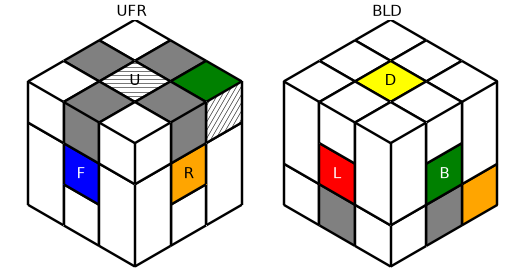

### Case 10

Execute `((U')^((y' (M4) y U)^-1))^-1: R2 L2 B2 F2 U F2 B2 L2 R2`.

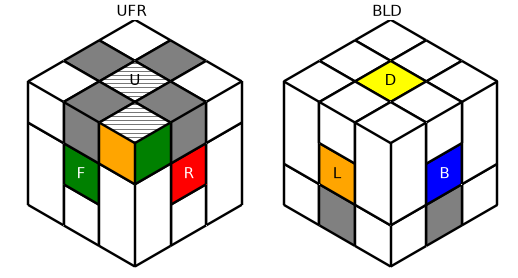

### Case 11

Execute `(M5 M22^3)^-1: B U L U' L' U L U' L' U L U' L' F D2 F' B'`.

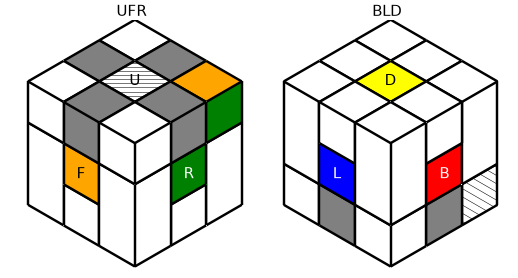

### Case 12

Execute `M22^-3: B U L U' L' U L U' L' U L U' L' B'`.

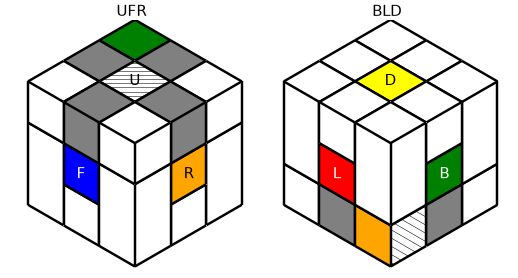

Also correct automatically after this stage: place Corner UFL.

## Stage 6: Solve Edge DR

This stage has 8 exact cases and 7 instruction families. It reduces the remaining possibilities from 124,416 to 15,552.

### Case 1

Execute `((y2 (M2) y2)^((y (M3) y' U)^-1))^-1: L2 B2 L2 U F2 R2 F2 U' L2 B2 L2`.

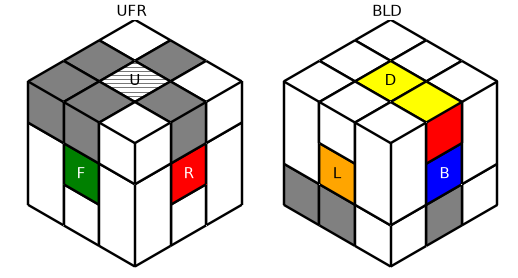

### Case 2

Execute `(U y' (M7) y M3 (y' (M7) y)^-1 U')^-1: U R L' B L R' B2 R2 B2 R L' B' L R' U'`.

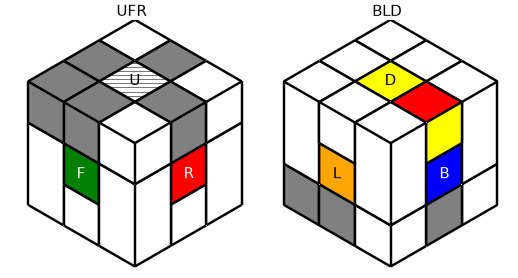

### Case 3

Execute `((y2 (M3) y2)^((y2 (M2) y2 U2)^-1))^-1: F2 R2 F2 U2 F2 L2 F2 U2 F2 R2 F2`.

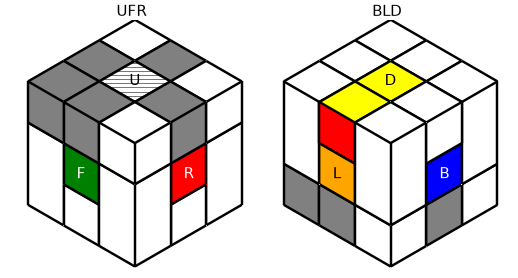

### Case 4

Execute `((y2 (M7) y2)^U M2 ((y2 (M7) y2)^U)^-1)^-1: U' F B' R B F' U B2 L2 B2 U' F B' R' B F' U`.

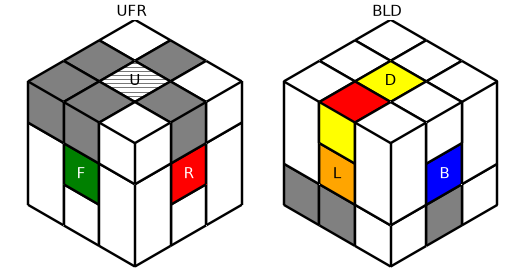

### Case 5

Skip — already correct

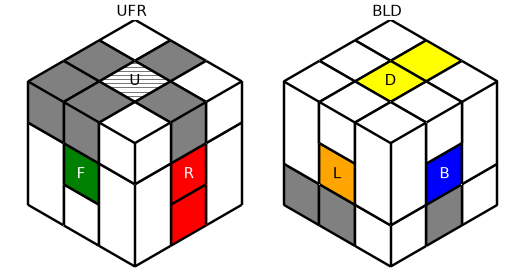

### Case 6

Execute `((y' (M5) y)^(y' (M7) y) y' (M12) y)^((y2 (M2) y2)^-1): F2 R2 F2 R L' B' L2 D2 L2 B L R' U R2 F2 R2 U' F2 R2 F2`.

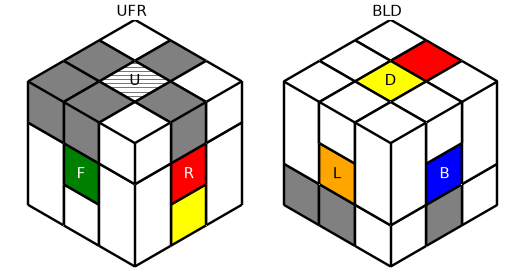

### Case 7

Execute `((y2 (M2) y2)^((y (M2) y' U')^-1))^-1: L2 F2 L2 U' F2 R2 F2 U L2 F2 L2`.

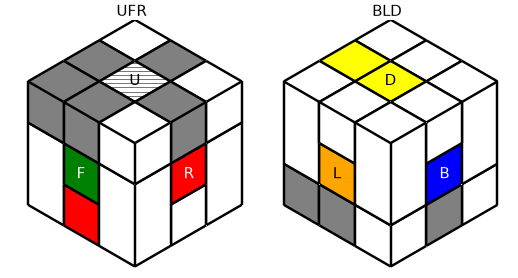

### Case 8

Execute `(y2 (M7) y2 y' (M3) y (y2 (M7) y2)^-1)^-1: F B' R B F' R2 F2 R2 F B' R' B F'`.

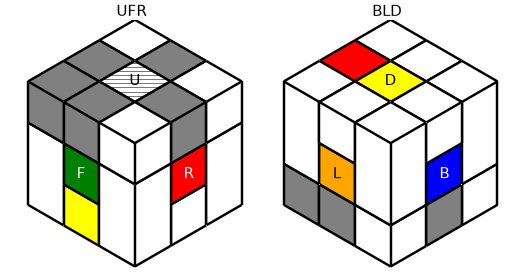

Also correct automatically after this stage: place Edge DR.

## Stage 7: Solve Edge DB

This stage has 6 exact cases and 5 instruction families. It reduces the remaining possibilities from 15,552 to 2,592.

### Case 1

Skip — already correct

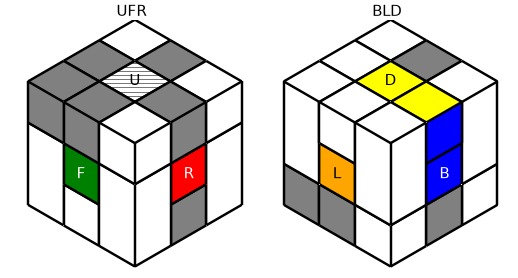

### Case 2

Execute `(((M9^(M8^-1) M13)^-1)^M8)^-1: B' F' D2 F2 R' F' B U' B2 L2 B2 U B' F R F' B`.

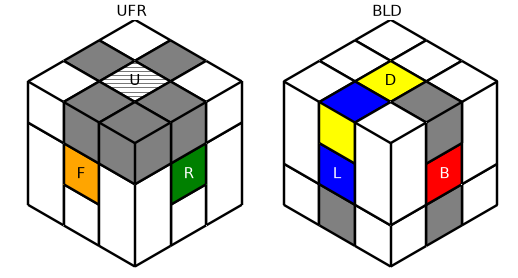

### Case 3

Execute `(y (M12) y' y2 (M3) y2 y (M12) y')^-1: U L2 B2 L2 U' F2 L2 F2 U L2 B2 L2 U'`.

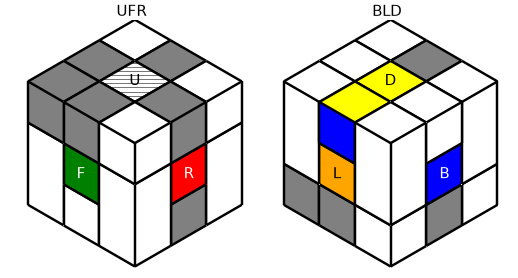

### Case 4

Execute `((y' (M7) y)^-1 M2 y' (M7) y)^-1: R L' B' L R' B2 L2 B2 R L' B L R'`.

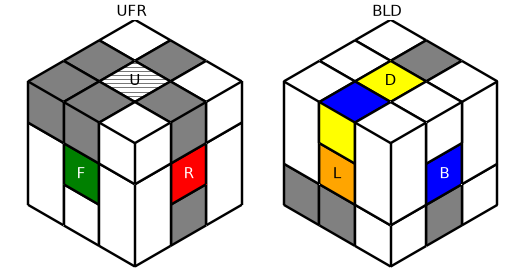

### Case 5

Execute `M9: B' F' D2 F B`.

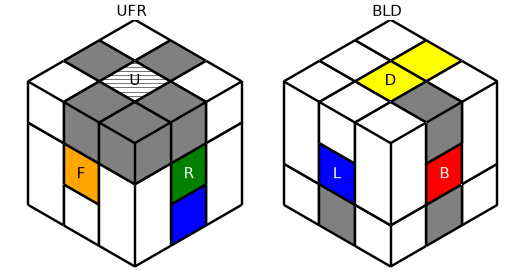

### Case 6

Execute `(M9 ((M9^(M8^-1) M13)^-1)^M8)^-1: B' F' D2 F2 R' F' B U' B2 L2 B2 U B' F R F2 D2 F B`.

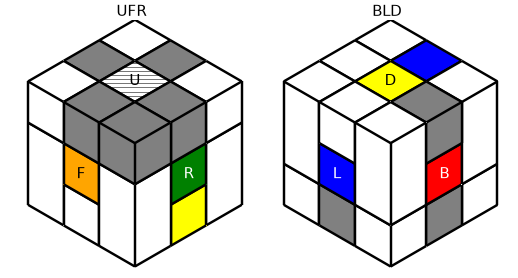

Also correct automatically after this stage: place Edge DB.

## Stage 8: Solve Corner UBL

This stage has 9 exact cases and 8 instruction families. It reduces the remaining possibilities from 2,592 to 288.

### Case 1

Skip — already correct

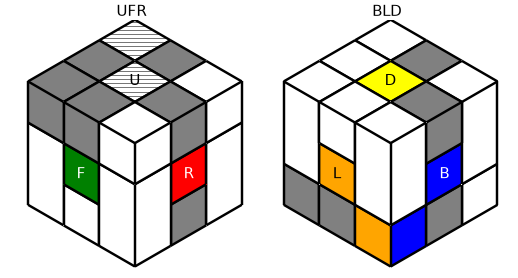

### Case 2

Execute `((((M30^-1)^(U'))^-1)^((())^-1))^-1: L2 F2 L2 U B L U L' U' B' L2 F2 L2 B U L U' L' B' U'`.

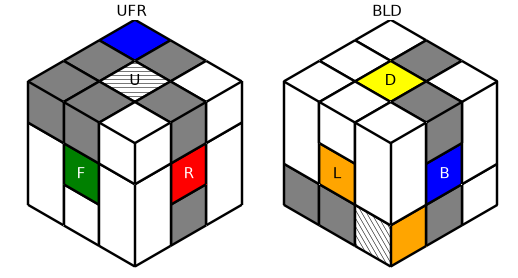

### Case 3

Execute `(((M30^-1)^(U'))^((())^-1))^-1: U B L U L' U' B' L2 F2 L2 B U L U' L' B' U' L2 F2 L2`.

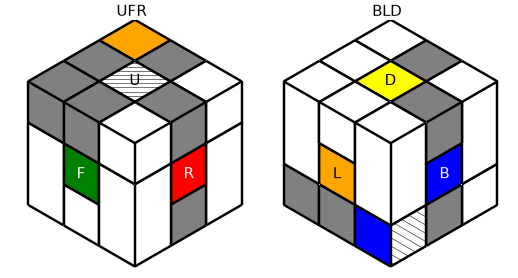

### Case 4

Execute `(([y' (M2) y, y2 (M28) y2]^((y' (M3) y)^-1))^((U2 y' (M3) y)^-1))^-1: U2 F U F' U' R' F' R' B2 R F R U F U' F' R2 B2 R2 U2`.

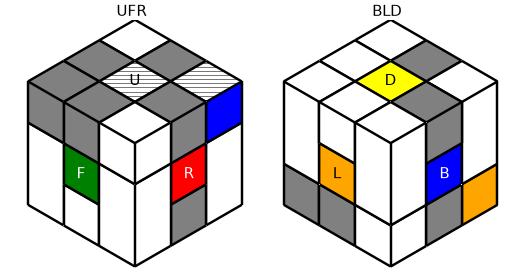

### Case 5

Execute `((y' (M29) y)^((U2 y2 (M3) y2)^-1))^-1: U2 R' F R U F U' F L2 F' U F' U' R' F' R F2 L2 F2 U2`.

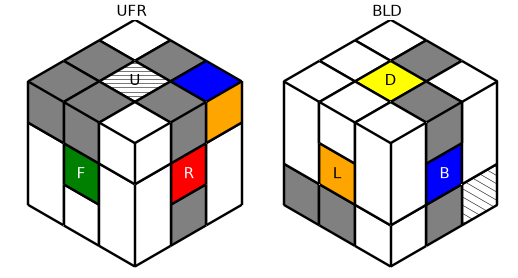

### Case 6

Execute `(((y2 (M28) y2)^-1)^U y2 (M12) y2 (((y2 (M28) y2)^-1)^U)^-1)^-1: U' R' F R U F U' F' U2 F2 L2 F2 U2 F U F' U' R' F' R U`.

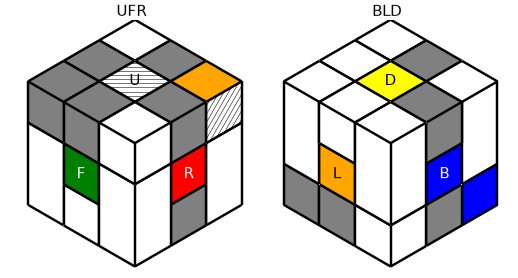

### Case 7

Execute `((y2 (M8) y2)^-1 y' (M3) y y2 (M8) y2)^-1: F' B L' B' F R2 F2 R2 F' B L B' F`.

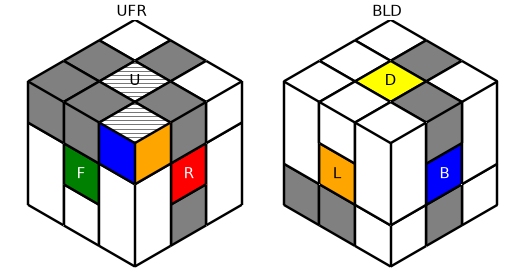

### Case 8

Execute `(((y' (M29) y)^-1)^((U (y2 (M22) y2)^-1)^-1))^-1: U F U R U' R' F' R' F R U F U' F L2 F' U F' U' R' F' R F2 L2 F' R U R' U' F' U'`.

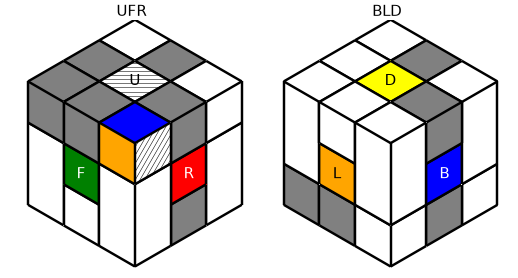

### Case 9

Execute `(((y' (M29) y)^-1)^((U y2 (M22) y2)^-1))^-1: U F R U R' U' F' R' F R U F U' F L2 F' U F' U' R' F' R F2 L2 F' U R U' R' F' U'`.

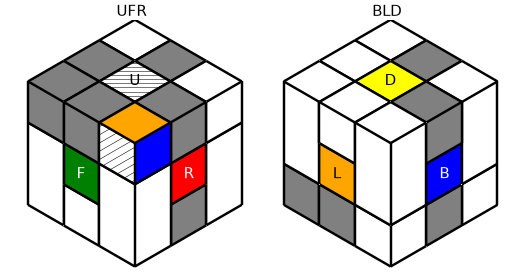

Also correct automatically after this stage: place Corner UBL.

## Stage 9: Solve Pair BL-DBL

This stage has 4 exact cases and 3 instruction families. It reduces the remaining possibilities from 288 to 72.

### Case 1

Skip — already correct

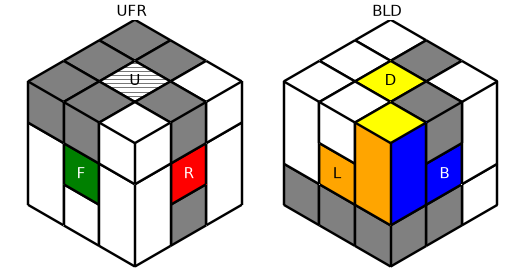

### Case 2

Execute `M31^-1: U2 L' U B2 L2 U B R2 B' U' L2 B2 U' L U2 B' F R' F' B L2 B2 L2 B' F R F' B`.

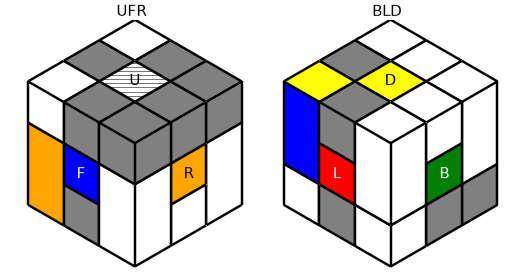

### Case 3

Execute `M31: B' F R' F' B L2 B2 L2 B' F R F' B U2 L' U B2 L2 U B R2 B' U' L2 B2 U' L U2`.

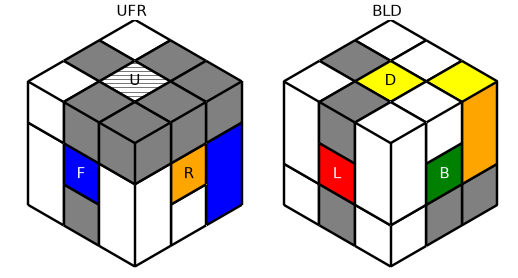

### Case 4

Execute `((y' (M5) y)^(U') y' (M9) y)^-1: R' L' D2 L R U R L D2 L' R' U'`.

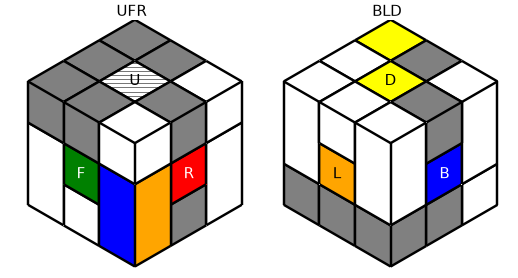

Also correct automatically after this stage: place Pair BL-DBL.

## Stage 10: Solve Corner UBR

This stage has 6 exact cases and 4 instruction families. It reduces the remaining possibilities from 72 to 12.

### Case 1

Skip — already correct

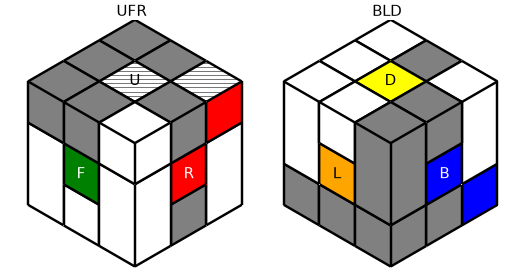

### Case 2

Execute `(((y' (M29) y)^-1 ([y' (M2) y, y2 (M28) y2])^-1)^(U'))^-1: U R2 B2 R2 F U F' U' R' F' R' B2 R F R U F U' F' R' F R U F U' F L2 F' U F' U' R' F' R F2 L2 F2 U'`.

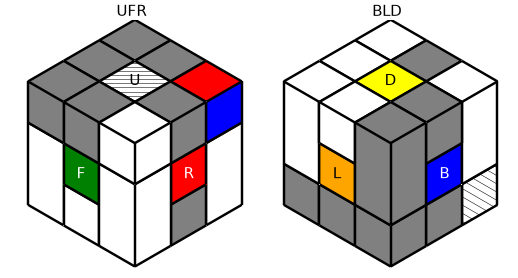

### Case 3

Execute `((y' (M29) y)^-1 ([y' (M2) y, y2 (M28) y2])^-1)^(U'): U F2 L2 F2 R' F R U F U' F L2 F' U F' U' R' F' R F U F' U' R' F' R' B2 R F R U F U' F' R2 B2 R2 U'`.

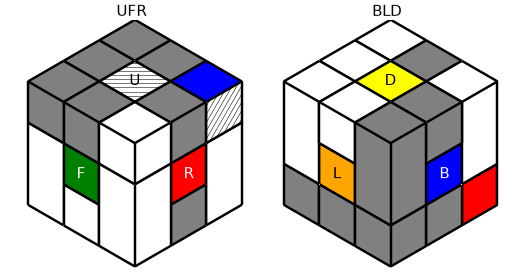

### Case 4

Execute `((y2 (M8) y2)^-1 y' (M3) y y2 (M8) y2 ((([y' (M2) y, y2 (M28) y2]^((y' (M3) y)^-1))^-1)^((U2 y' (M3) y)^-1))^-1)^-1: U2 F U F' U' R' F' R' B2 R F R U F U' F' R2 B2 R2 U2 F' B L' B' F R2 F2 R2 F' B L B' F`.

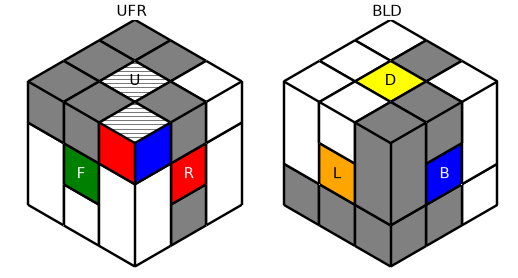

### Case 5

Execute `(((y2 (M28) y2)^-1)^U y2 (M12) y2 (((y2 (M28) y2)^-1)^U)^-1 (y2 (M8) y2)^-1 y' (M3) y y2 (M8) y2 ((y2 (M28) y2)^-1)^U y2 (M12) y2 (((y2 (M28) y2)^-1)^U)^-1)^-1: U' R' F R U F U' F' U2 F2 L2 F2 U2 F U F' U' R' F' R U F' B L' B' F R2 F2 R2 F' B L B' F U' R' F R U F U' F' U2 F2 L2 F2 U2 F U F' U' R' F' R U`.

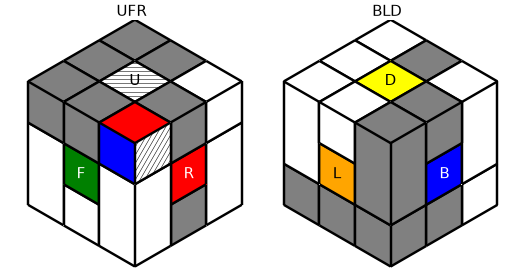

### Case 6

Execute `((y2 (M8) y2)^-1 y' (M3) y y2 (M8) y2 (y' (M29) y)^((U2 y2 (M3) y2)^-1))^-1: U2 R' F R U F U' F L2 F' U F' U' R' F' R F2 L2 F2 U2 F' B L' B' F R2 F2 R2 F' B L B' F`.

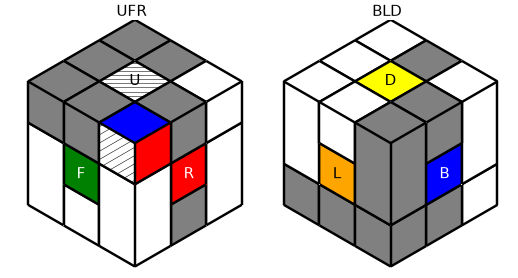

Also correct automatically after this stage: place Corner UBR; place Corner UFR; place Edge DL; place Edge DF; fully solve Corner UFR.

## Stage 11: Solve Pair BR-DBR

This stage has 3 exact cases and 2 instruction families. It reduces the remaining possibilities from 12 to 4.

### Case 1

Skip — already correct

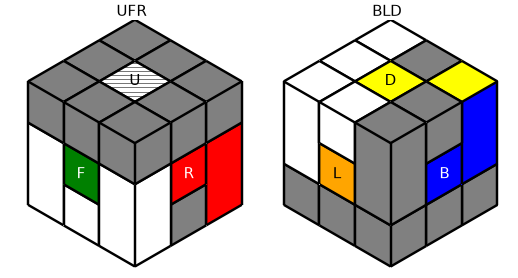

### Case 2

Execute `((([M2, ([M3, M23^-1])^-1])^-1)^(M3^-1))^-1: B2 R2 L2 B2 L' U B2 L2 U B R2 B' U' L2 B2 U' L B2 R2 L2 R2 B2 L' U B2 L2 U B R2 B' U' L2 B2 U' L B2 R2 B2`.

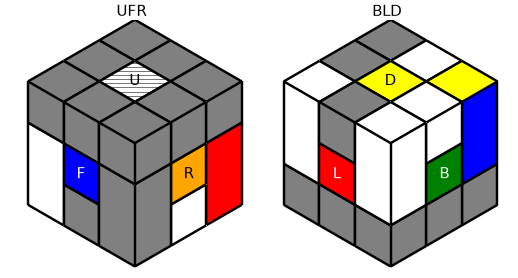

### Case 3

Execute `([M2, ([M3, M23^-1])^-1]^(M3^-1))^-1: B2 R2 B2 L' U B2 L2 U B R2 B' U' L2 B2 U' L B2 R2 L2 R2 B2 L' U B2 L2 U B R2 B' U' L2 B2 U' L B2 L2 R2 B2`.

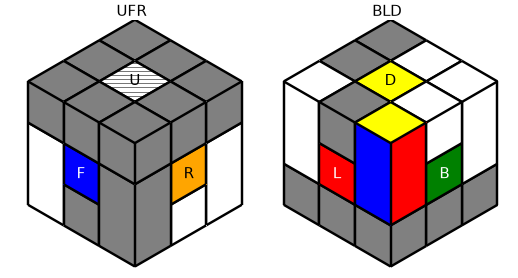

Also correct automatically after this stage: place Pair BR-DBR.

## Stage 12: Solve Pair FL-DFL

This stage has 2 exact cases and 1 instruction family. It reduces the remaining possibilities from 4 to 2.

### Case 1

Skip — already correct

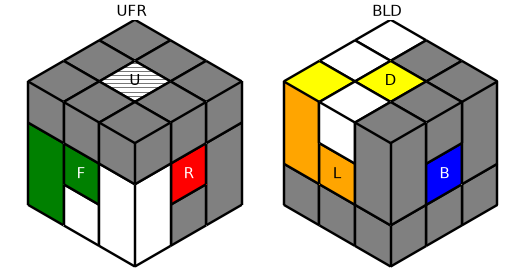

### Case 2

Execute `(((y2 (M28) y2)^-1)^U y2 (M12) y2 (((y2 (M28) y2)^-1)^U)^-1 (y2 (M2) y2)^((y (M3) y' U)^-1) U^(y' (M4) y) (y (M22) y')^-1 y2 (M28) y2 y' (M8) y y' (M9) y (((M30^-1)^(U'))^-1)^((())^-1) ((([y2 (M2) y2, ([y2 (M3) y2, (y2 (M23) y2)^-1])^-1])^-1)^((y2 (M3) y2)^-1))^-1)^-1: F2 L2 F2 R' U F2 R2 U F L2 F' U' R2 F2 U' R F2 L2 R2 L2 F2 R' U F2 R2 U F L2 F' U' R2 F2 U' R F2 R2 L2 F2 L2 F2 L2 U B L U L' U' B' L2 F2 L2 B U L U' L' B' U' R' L' D2 L2 F' L' F R U F U' F' L F U F' U' L' F2 B2 L2 R2 U' R2 L2 B2 F2 L2 B2 L2 U F2 R2 F2 U' L2 B2 L2 U' R' F R U F U' F' U2 F2 L2 F2 U2 F U F' U' R' F' R U`.

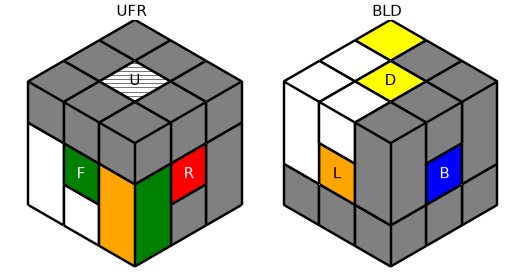

Also correct automatically after this stage: place Pair FL-DFL; place Pair FR-DFR; fully solve Pair FR-DFR.

## Stage 13: Orient Edge DL

This stage has 2 exact cases and 1 instruction family. It reduces the remaining possibilities from 2 to 1.

### Case 1

Skip — already correct

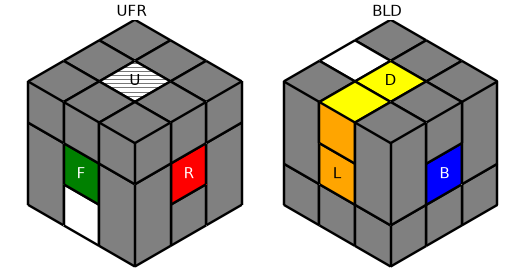

### Case 2

Execute `((y' (M5) y)^((y' (M7) y)^-1) y' (M14) y)^((y2 (M3) y2)^-1): F2 L2 F2 R L' B L2 D2 L2 B' L R' U' R2 F2 R2 U F2 L2 F2`.

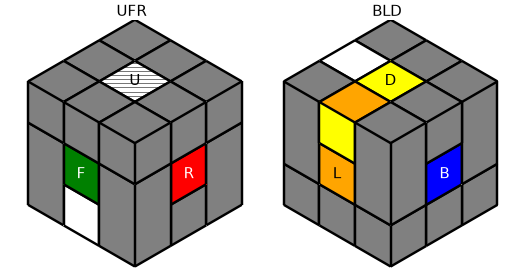

Also correct automatically after this stage: fully solve Edge DF.

After the final stage every modeled corner and edge sticker is solved. Unmarked center spin and independent virtual-core spin are outside this model.


In [2]:
repertoire = c.template_human_repertoire(analysis, preference=preference, backend="auto",
    optimization_seconds=120, progress=None,
)
display(Markdown(repertoire.write_guide(diagram_mode=diagram_mode, face_colors=face_colors)))


Optional shape graph. Configure and run the following cell when you want to draw the graph. `graph_view="auto"` draws small graphs and summarizes graphs above 1,000 shapes. Use `"local"` for a bounded neighborhood, or explicitly set `graph_view="full"` to draw every shape. Full layouts of large graphs can be expensive.


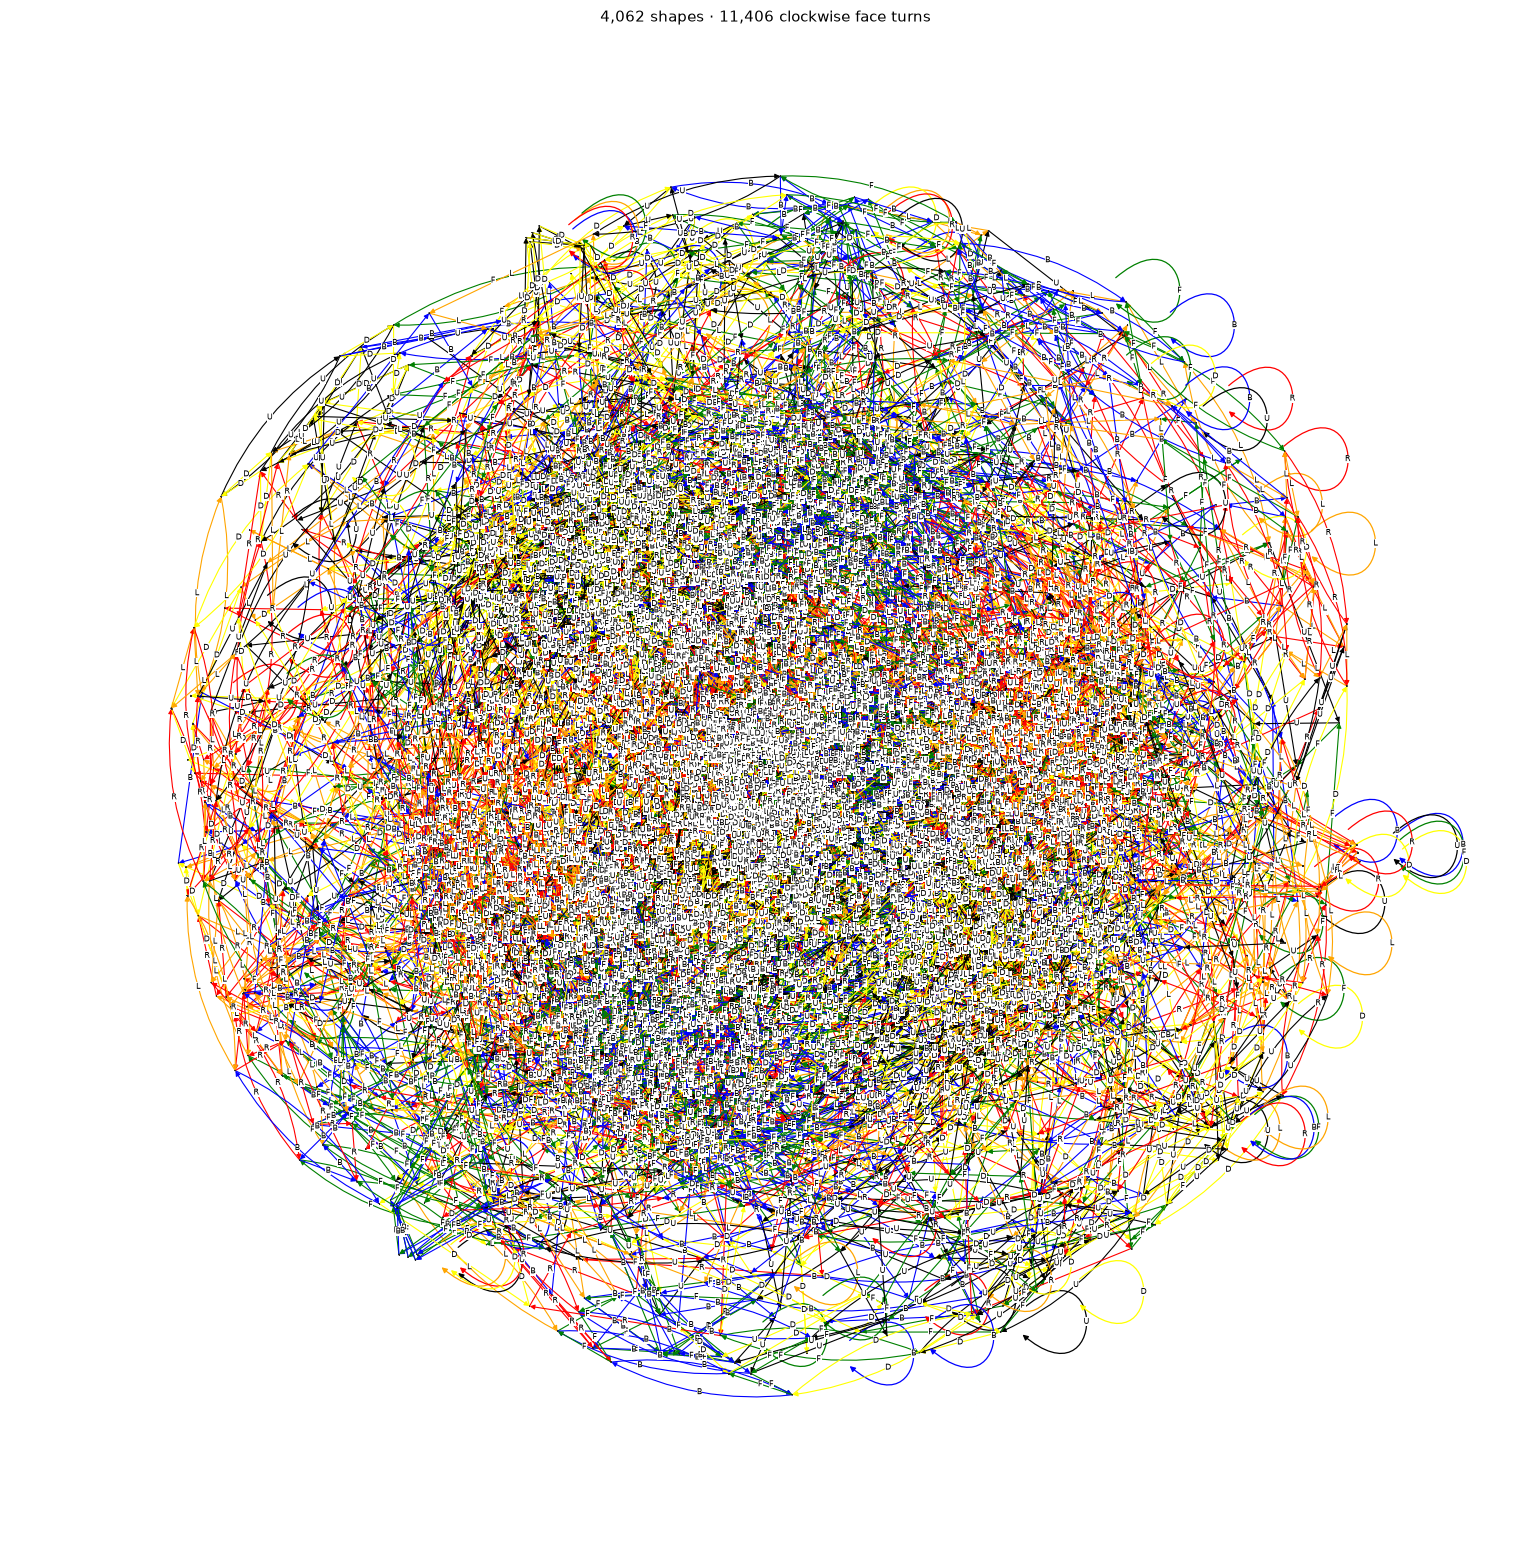

In [ ]:
import matplotlib.pyplot as plt

graph_view = "auto"  # "summary", "local", or explicit "full"
graph_max_vertices = 1000  # full auto drawings and local neighborhoods are bounded
graph_radius = 2  # used only for the local view
graph_layout = "symmetry"
graph_show_shapes = True
graph_edge_labels = True
graph_figsize = None  # automatic; override with (width, height) in inches
graph_shape_size = None  # automatic; override with a width in inches

shape_graph = c.explore(bandage)
graph_figure = c.draw_bandage_graph(
    shape_graph, view=graph_view, max_vertices=graph_max_vertices, radius=graph_radius,
    layout=graph_layout, show_shapes=graph_show_shapes,
    edge_labels=graph_edge_labels, face_colors=face_colors,
    diagram_mode=diagram_mode, figsize=graph_figsize, shape_size=graph_shape_size,
)
display(graph_figure)
plt.close(graph_figure)
